## 1. 初期設定

In [1]:
# 基本モジュール
import sys, os
from IPython.display import display, HTML, clear_output, update_display, Image
import pyFAI
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

# 自作モジュール
sys.path.append(r"C:\Users\okaza\pythonenv")
from modules.Mytools.handle_ipynb import save_pickle
from modules.Mytools.Tools import his2array

## 2. キャリブレーションファイルの作成

まず、tifファイルを作成します。

In [2]:
# CeO2のhisファイルを指定
calib_his = r"D:\DATA\SPring-8-2025-Nov\CeO2_20251028\CeO2_FPD_MgS400_20251028_0.his"

In [3]:
# データ読み込み
calib = his2array(calib_his)

# 同じ名前（拡張子だけ変更）で保存する
outputtif = os.path.splitext(calib_his)[0] + ".tif"
cv2.imwrite(outputtif, calib)

# 出力
print("Save tiff: " + os.path.abspath(outputtif))

Save tiff: D:\DATA\SPring-8-2025-Nov\CeO2_20251028\CeO2_FPD_MgS400_20251028_0.tif


次に、pyFAI-calib2を使用してponiファイルを作成します。  
pyFAI-calib2の使用方法は以下のサイトを参考にして下さい。  
https://www.silx.org/doc/pyFAI/latest/usage/cookbook/calib-gui/index.html

In [ ]:
!pyFAI-calib2

## 2. poniファイルの確認

最後に作成したponiファイルのテストをします。  
セルを動かすと、pdindexerで読み込むことができるcsvが作成されますので、ipanalyzerで切り開いたデータと比較してみてください。

In [4]:
# 作成したponiファイルのパス
poni_path = r"D:\DATA\SPring-8-2025-Nov\CeO2_20251028\IPanalyzer_FPD_MgS400_EH2_20251210_okazaki.poni"

# 参照するFPDデータ（hisファイル）
ref_his = r"D:\DATA\SPring-8-2025-Nov\Okazaki\UODE31\XRD1\UODE31_0.his"

Caking: success!
Save csv: D:\DATA\SPring-8-2025-Nov\Okazaki\UODE31\XRD1\UODE31_0.csv


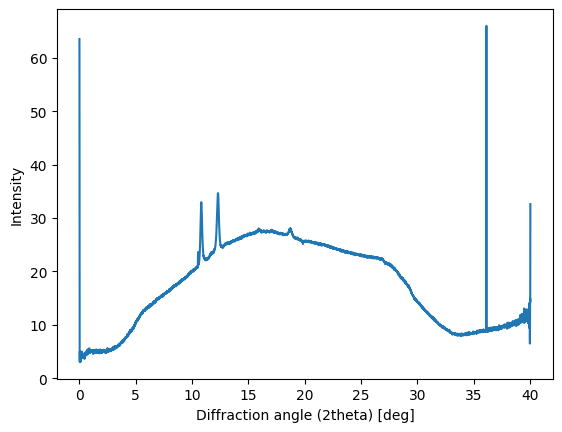

In [5]:
# データを読み込み
data = his2array(ref_his)

# 切り開きを実行
ai = pyFAI.load(poni_path)
tth, intensity = ai.integrate1d(
    data.astype(np.float32),
    npt = 4000,
    unit = "2th_deg",
    method = "ocl"
)
print("Caking: success!")

# データ保存
csvfile_path = os.path.splitext(ref_his)[0] + ".csv"
df = pd.DataFrame([tth, intensity]).T.to_csv(
    csvfile_path,
    index = False,
    header = False
)
print("Save csv: " + os.path.abspath(csvfile_path))

# 出力
plt.plot(tth, intensity)
plt.xlabel("Diffraction angle (2theta) [deg]")
plt.ylabel("Intensity")
plt.show()
plt.close()